In [23]:
from pathlib import Path
import math,random,os,sys, importlib, time,copy
import pickle, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, kstest, cramervonmises, chi2, ks_2samp
from scipy import stats

import torch
from torch.utils.data import DataLoader
from joblib import Parallel, delayed
# Repo paths
ROOT = Path.cwd().resolve().parents[0]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Local modules
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)
import train.training_clean as train_training; importlib.reload(train_training)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, compute_mu_safety_map
from data.datasets import SpringDataset, make_sequence_pairs
from data.plotting import plot_x_safety_map, plot_mu_safety_map
from train.models import build_cond_gru_model, EncoderOnly

from train.training_clean import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_stability_classification,
    eval_regime_batch_stats
)
from train.eval import encode_to_latent

from train.losses import mmd2_unif, energy_distance_unif
from train.training_clean import (
    DivergenceConfig,
    StabilityConfig,
    RegimeConfig,
    TrainingConfig,
    train_eval_epoch,
    train_eval_epoch_enc_only,
)
import hypo_test.stats_tests as test_mod; importlib.reload(test_mod)
from hypo_test.stats_tests import uniformity_pvalues_all,ecdf

# Global config
class Cfg:
    seed = 1
    n_samples = 5000
    T = 10.0
    dt = 0.05
    stride = 1
    dist_mean = np.array([0., 0.])
    dist_cov = np.diag([1., 1.])
    batch_train = 1024
    batch_val = 1024
    epochs = 100
    lr = 3e-3
    weight_decay = 1e-5
    lr_enc = 3e-3
    weight_decay_enc = 0
    lambda_mmd = 1e-2
    d_x = 2
    d_o = 1
    d_v = 1
    d_h = 128
    hidden_enc = 512
    hidden_dec = 128
    B_bins = 20  # chi-square bins
    tau = 1
    time_window = (6, 10) # inspection window
    lambda_stability = 0
    lambda_regime = 0

# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)


device: cuda


In [24]:
# 1. train two models: proposed model and encoder only model
# 2. visualize their latent variable uniformity
# 3. perturb data, change mean and variance, and check how latent shfits, say divergence between shifted latent to uniformity


In [25]:
z_0 = np.array([0.0, 0.0]) # baselien config
params = SpringParams(mass=1.0, damping=1.0, stiffness=2.0) # paramters theta

X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
)

traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type="sin", config=z_0)
s = traj["s"]                           # (N, T_full)
assert X.shape[0] == s.shape[0]


y = check_safety(
    traj=traj,
    threshold=Cfg.tau,
    window=Cfg.time_window,
).astype(np.float32)


o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

print("Shapes -> X:", x_np.shape, "trajectory shape:", s.shape)

N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx], y=y[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx], y=y[va_idx])

train_loader = DataLoader(train_ds, batch_size=Cfg.batch_train, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=Cfg.batch_val, shuffle=False)

# print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")



Shapes -> X: (5000, 2) trajectory shape: (5000, 201)


In [ ]:
lambda_mmd = 0.1

div_fn = mmd2_unif
div_kwargs = {"sigmas": None, "low_discrepancy": True}

train_cfg = TrainingConfig(
    divergence=DivergenceConfig(lambda_mmd=lambda_mmd, fn=mmd2_unif, kwargs=div_kwargs),
    stability=StabilityConfig(
        lambda_stability=0,
        threshold=1.0,
        window=(2.0, 8.0),
    ),
    regime=RegimeConfig(
        lambda_regime=0,
        gamma=0.9,
        delta_safe=0.05,
        delta_unsafe=0.2,
    ),
)

baseline_model_cfg = DivergenceConfig(
    lambda_mmd=lambda_mmd,
    fn=div_fn,
    kwargs=div_kwargs,
)

model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1,
).to(device)

model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)

Cfg.epochs = 100
history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss, val_rec, val_div = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        device=device,
        config=train_cfg,
        val_loader=val_loader if use_val else None,
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        device=device,
        divergence=baseline_model_cfg,
        val_loader=val_loader if use_val else None,
    )

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_recon": val_rec,
        "val_divergence": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        msg = f"[{epoch:02d}] train-loss={tr_loss:.6f}"
        if use_val:
            msg += (
                f"  val-recon={val_rec:.6f}  val-divergence={val_div:.6f}"
                f"  train-divergence (enc)={tr_div_enc:.6f}"
                f"  val-divergence (enc)={val_div_enc:.6f}"
            )
        print(msg)

if use_val and best_state is not None:
    model.load_state_dict(best_state)

# pd.DataFrame(history).tail()


[01] train-loss=0.146670  val-recon=0.092745  val-divergence=0.039079  train-divergence (enc)=0.217108  val-divergence (enc)=0.039797
[10] train-loss=0.003079  val-recon=0.003093  val-divergence=0.000436  train-divergence (enc)=0.006352  val-divergence (enc)=0.003902
[20] train-loss=0.000292  val-recon=0.000258  val-divergence=0.000127  train-divergence (enc)=0.000810  val-divergence (enc)=0.001455
[30] train-loss=0.000100  val-recon=0.000086  val-divergence=0.000199  train-divergence (enc)=0.001935  val-divergence (enc)=-0.000191
[40] train-loss=0.000000  val-recon=0.000044  val-divergence=0.000625  train-divergence (enc)=0.000137  val-divergence (enc)=0.000512
[50] train-loss=0.000207  val-recon=0.000063  val-divergence=-0.000224  train-divergence (enc)=0.000047  val-divergence (enc)=0.000136
[60] train-loss=0.000184  val-recon=0.000031  val-divergence=0.000821  train-divergence (enc)=0.000254  val-divergence (enc)=0.000725
[70] train-loss=0.000201  val-recon=0.000308  val-divergence

,epoch,train_loss,val_recon,val_divergence,train_div (enc-only),val_divergence (enc-only)
95,96,0.000008,0.000047,0.002078,-0.000357,-0.000031
96,97,0.000156,0.000179,0.001028,-0.000199,0.000138
97,98,0.000287,0.000639,0.000012,0.000230,0.000482
98,99,0.000702,0.000327,0.000188,0.001183,0.001370
99,100,0.000144,0.000329,0.001673,0.000947,0.000443


[Uniformity p-values vs Unif(0,1)]


,split,method,KS_p,CvM_p,MMD_p,ED_p,Chi2
0,train,proposed,0.011640,0.016429,1.0,1.0,0.000128
1,train,baseline,0.005797,0.000786,1.0,1.0,0.000128
2,test,proposed,0.106405,0.089660,1.0,1.0,0.003511
3,test,baseline,0.048842,0.056030,1.0,1.0,0.003511


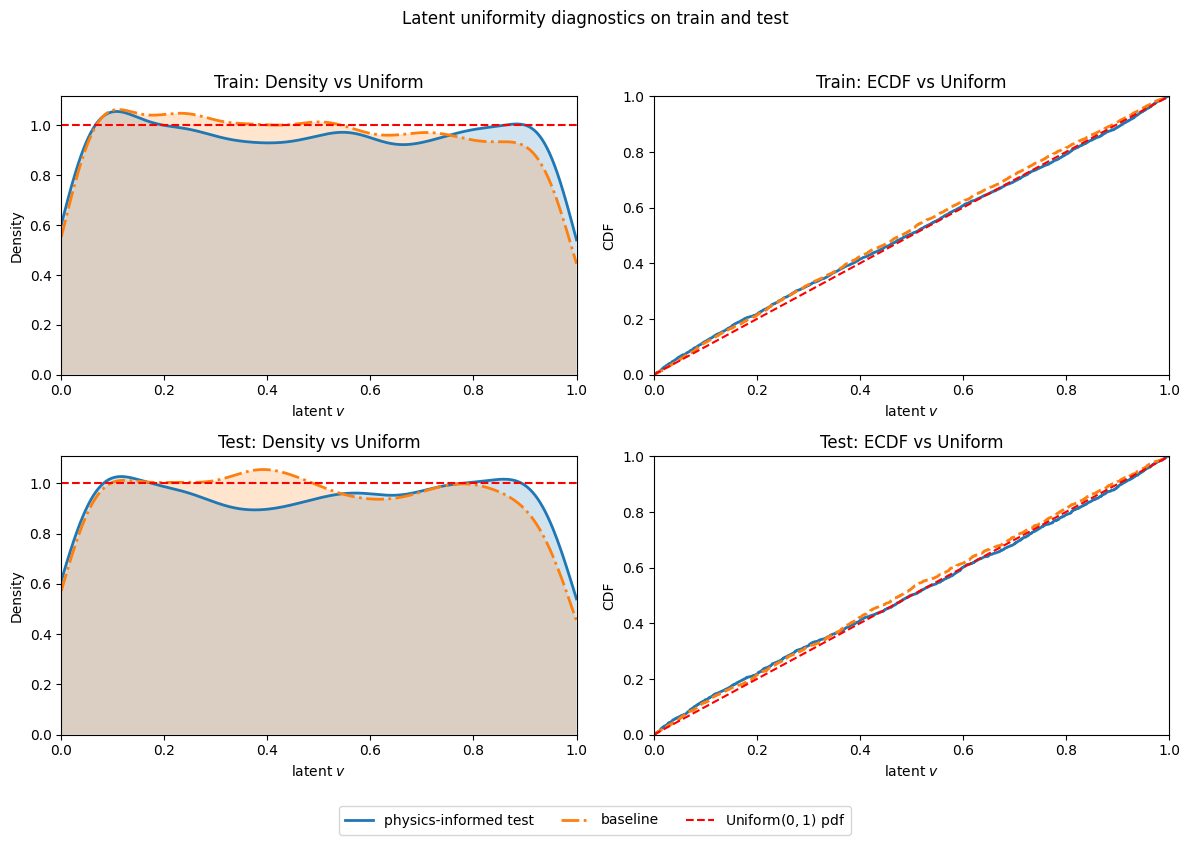

In [27]:

X_splits = {
    "train": x_np[tr_idx],
    "val": x_np[va_idx],
    "test": sample_x(
        n_samples=2000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=1,
    ).astype(np.float32),
}

# -----------------------
# 1) compute latents per split
# -----------------------
latents = {}
for split_name in ["train", "test"]:
    X = X_splits[split_name]
    latents[split_name] = {
        "proposed": encode_to_latent(model, X, device)[:, 0],
        "baseline": encode_to_latent(model_enc, X, device)[:, 0],
    }

# Optional clipping for uniform diagnostics
# for split_name in latents:
#     latents[split_name]["proposed"] = np.clip(latents[split_name]["proposed"], 0.0, 1.0)
#     latents[split_name]["baseline"] = np.clip(latents[split_name]["baseline"], 0.0, 1.0)

# -----------------------
# 2) p-values table
# -----------------------
rows = []
for split_name in ["train", "test"]:
    v_np = latents[split_name]["proposed"]
    v0_np = latents[split_name]["baseline"]

    pvals = uniformity_pvalues_all(v_np, v0_np, device=device, B=0, seed=0)

    for method_name in ["proposed", "baseline"]:
        row = {"split": split_name, "method": method_name}
        for key, value in pvals[method_name].items():
            if "stat" in key:
                continue
            row[key] = value
        rows.append(row)

pvals_df = pd.DataFrame(rows)
print("[Uniformity p-values vs Unif(0,1)]")
display(pvals_df)

# -----------------------
# 3) make 2x2 plot
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for row_idx, split_name in enumerate(["train", "test"]):
    v_np = latents[split_name]["proposed"]
    v0_np = latents[split_name]["baseline"]

    grid = np.linspace(0, 1, 400)
    kde_v = gaussian_kde(v_np)(grid)
    kde_v0 = gaussian_kde(v0_np)(grid)

    x1, y1 = ecdf(v_np)
    x2, y2 = ecdf(v0_np)

    # Left: KDE vs uniform pdf
    ax = axes[row_idx, 0]
    ax.plot(grid, kde_v, linewidth=2, label="physics-informed test")
    ax.fill_between(grid, 0, kde_v, alpha=0.20)
    ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline")
    ax.fill_between(grid, 0, kde_v0, alpha=0.20)
    ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"latent $v$")
    ax.set_ylabel("Density")
    ax.set_title(f"{split_name.capitalize()}: Density vs Uniform")

    # Right: ECDF vs uniform cdf
    ax = axes[row_idx, 1]
    ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
    ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
    ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"latent $v$")
    ax.set_ylabel("CDF")
    ax.set_title(f"{split_name.capitalize()}: ECDF vs Uniform")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Latent uniformity diagnostics on train and test", y=1.02)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## Data Shift: Mean Perturbation

Let $\mathbb{P}_0 = \mathcal{N}(\mu, \Sigma)$, where
$
\mu=\begin{bmatrix}0\\0\end{bmatrix},
\Sigma=\begin{bmatrix}1 & 0\\ 0 & 1\end{bmatrix}.
$
In mean perturbation case, we consider $\mathbb{P}_1 = \mathcal{N}(\mu', \Sigma)$, with $\mu'=\begin{bmatrix}0\\0\end{bmatrix},$


In [28]:
# for mu in each grid, compute how latent distribtuon diviate from unifrom, say under the null and under the alternative, 
# loop over mu:
#   for each mu, generate Xs: 
#       encode Xs to latent vs (two models)
#       compute vs divergence to uniform distribution
# plot divergence vs mu 

# setting 1 (under null): with mu=(0,0), set mu' = (0,delta), say delta = 0 to 1 with stepsize 0.1
# setting 2 (null to alternative): with mu=(0,0), set mu' = (delta,0), say delta = 0 to 1 with stepsize 0.1, after say delta = 0.5, it cross boundary, config change to unsafe
# setting 3 (under alternative): with mu=(0,0), set mu' = (-1,delta), say delta = 0 to 1 with stepsize 0.1, always alternative



## Testing

In [20]:

def ks_pvalue_to_uniform(v_np: np.ndarray) -> float:
    """
    KS test p-value for H0: v ~ Uniform(0,1).
    Assumes v is in [0,1]. If not, clip (or better: fix encoder output).
    """
    v = np.asarray(v_np, dtype=float).ravel()
    # If your latent is *supposed* to be in [0,1], clipping is reasonable for diagnostics.
    v = np.clip(v, 0.0, 1.0)
    return float(kstest(v, "uniform", args=(0.0, 1.0)).pvalue)

def ks_2sample_pvalue(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    # if your latent is supposed to be in [0,1], you can optionally clip:
    # x = np.clip(x, 0.0, 1.0); y = np.clip(y, 0.0, 1.0)
    return float(ks_2samp(x, y, alternative="two-sided", method="asymp").pvalue)


def sweep_direction_parallel_twosample_ks(
    mu_base,
    direction,
    deltas,
    *,
    n_samples=2000,
    cov=np.diag([1., 1.]),
    truncate_box=None,
    seed=1,
    n_reps=10,
    n_jobs=-1,
    backend="threading",
):
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=len(deltas) * n_reps, dtype=np.uint32)
    cov = np.asarray(cov, float)

    def one(delta, rep_seed):
        rep_seed = int(rep_seed)
        mu_shift = np.asarray(mu_base, float) + float(delta) * np.asarray(direction, float)

        # baseline sample
        X0 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": np.asarray((0,0), float), "cov": cov},
            seed=rep_seed,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # shifted sample (different seed to avoid identical draws)
        X1 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu_shift, "cov": cov},
            seed=rep_seed + 99991,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # encode both samples for both models
        v0_p = encode_to_latent(model,     X0, device)[:, 0]
        v1_p = encode_to_latent(model,     X1, device)[:, 0]
        v0_b = encode_to_latent(model_enc, X0, device)[:, 0]
        v1_b = encode_to_latent(model_enc, X1, device)[:, 0]

        # two-sample KS p-values
        p_p = ks_2sample_pvalue(v0_p, v1_p)
        p_b = ks_2sample_pvalue(v0_b, v1_b)

        return float(delta), float(mu_shift[0]), float(mu_shift[1]), p_p, p_b

    tasks = [(delta, seeds[i * n_reps + j]) for i, delta in enumerate(deltas) for j in range(n_reps)]
    results = Parallel(n_jobs=n_jobs, backend=backend)(delayed(one)(delta, s) for delta, s in tasks)

    rows = []
    for i, delta in enumerate(deltas):
        chunk = results[i * n_reps : (i + 1) * n_reps]
        p_p = np.array([r[3] for r in chunk], dtype=float)
        p_b = np.array([r[4] for r in chunk], dtype=float)
        mu1, mu2 = chunk[0][1], chunk[0][2]

        rows.append({
            "delta": float(delta),
            "mu1": float(mu1),
            "mu2": float(mu2),
            'pval': p_p,
            'pval_base': p_b,
            "ks_p_prop_mean": float(np.mean(p_p)),
            "ks_p_base_mean": float(np.mean(p_b)),
            "ks_p_prop_std":  float(np.std(p_p)),
            "ks_p_base_std":  float(np.std(p_b)),

        })

    return pd.DataFrame(rows)


In [29]:
deltas = np.linspace(0, 1, 21)
truncate_box = (-3.0, 3.0)
n_reps = 50
n_jobs=15

df1 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)
df2 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(1,0), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)
df3 = sweep_direction_parallel_twosample_ks(mu_base=(-1,0), direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)


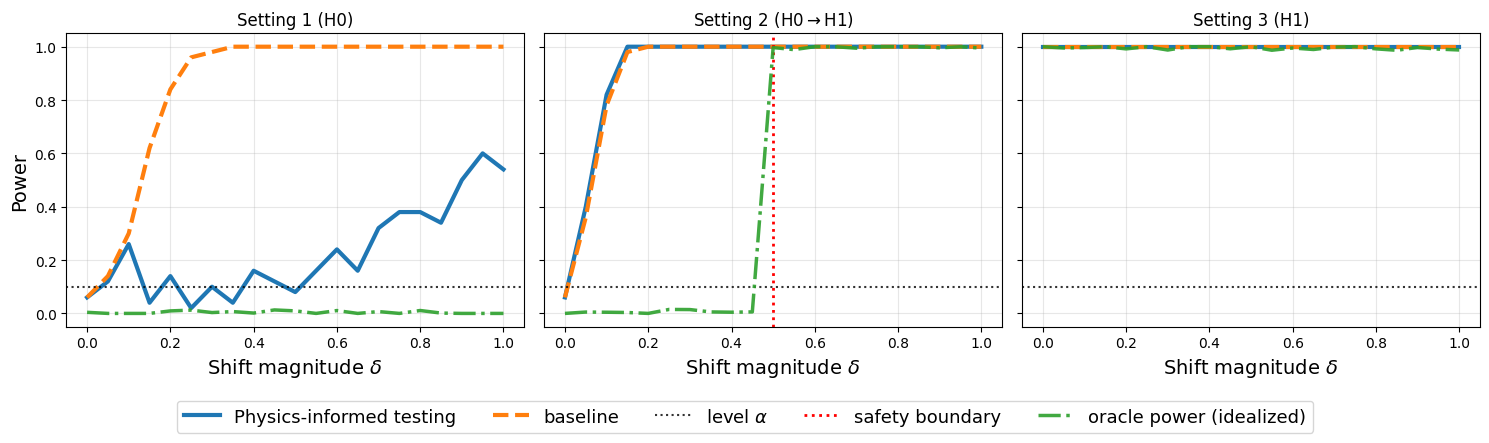

In [30]:

def plot_power_three(df1, df2, df3, *, alpha=0.1, boundary_delta=0.5, jitter=0.015, seed=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    titles = [
        r"Setting 1 (H0)",
        r"Setting 2 (H0$\to$H1)",
        r"Setting 3 (H1)",
    ]

    rng = np.random.default_rng(seed)

    for k, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles), start=1):
        delta = df["delta"].to_numpy()

        # empirical power from p-values
        rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
        rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()

        ax.plot(delta, rej_prop, lw=3, label=r"Physics-informed testing")
        ax.plot(delta, rej_base, lw=3, ls="--", label="baseline")

        # alpha line with label (only label once to avoid duplicate legend entries)
        ax.axhline(alpha, color="k", ls=":", lw=1.5, alpha=0.8,
                   label=(r"level $\alpha$" if k == 2 else None))

        # safety boundary (only in setting 2, keep label once)
        if title.startswith("Setting 2"):
            ax.axvline(boundary_delta, color="red", ls=":", lw=2,
                       label="safety boundary")

        # oracle/idealized power curve
        if title.startswith("Setting 1"):
            oracle = np.zeros_like(delta)
        elif title.startswith("Setting 2"):
            oracle = (delta >= boundary_delta).astype(float)
        else:  # Setting 3
            oracle = np.ones_like(delta)

        # jitter so it doesn't overlap perfectly
        oracle_j = np.clip(oracle + rng.uniform(-jitter, jitter, size=oracle.shape), 0.0, 1.0)

        # plot oracle (step-ish)
        ax.plot(delta, oracle_j, lw=2.5, ls="-.", alpha=0.9,
                label=(r"oracle power (idealized)" if k == 2 else None))

        ax.set_xlabel(r"Shift magnitude $\delta$",fontsize=14)
        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"Power",fontsize=14)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.12), fontsize=13)

    fig.tight_layout()
    plt.show()
 
# usage
alpha=0.1
plot_power_three(df1, df2, df3, alpha=alpha, boundary_delta=0.5)


In [ ]:
import pandas as pd

dfs = {
    "df1": df1,
    "df2": df2,
    "df3": df3,
}

summary_frames = []

for name, df in dfs.items():
    # pick method columns = everything except metadata columns
    meta_cols = {"delta", "rep", "seed", "mu_base", "direction"}
    method_cols = [c for c in df.columns if c not in meta_cols]

    power_df = (
        df.groupby("delta")[method_cols]
        .mean()
        .reset_index()
    )
    power_df.insert(0, "setting", name)
    summary_frames.append(power_df)

summary_df = pd.concat(summary_frames, ignore_index=True)


,setting,delta,mu1,mu2,pval,pval_base,ks_p_prop_mean,ks_p_base_mean,ks_p_prop_std,ks_p_base_std
0,df1,0.00,0.0,0.00,"[0.6034104769550357, 0.19349417513645772, 0.38...","[0.19349417513645772, 0.988073253089497, 0.168...",5.929212e-01,5.184946e-01,3.019239e-01,3.043841e-01
1,df1,0.05,0.0,0.05,"[0.3838459854305949, 0.18065010558325945, 0.76...","[0.6566398438826627, 0.025642857480321024, 0.5...",4.782395e-01,4.248537e-01,3.115998e-01,2.810949e-01
2,df1,0.10,0.0,0.10,"[0.08593507897696173, 0.1358503457034147, 0.09...","[0.007777394781266978, 0.05242538454463708, 0....",4.227333e-01,3.481478e-01,3.138303e-01,2.955024e-01
3,df1,0.15,0.0,0.15,"[0.7866588536437675, 0.9563931502431962, 0.342...","[0.003627538364235945, 0.6566398438826686, 0.6...",5.599905e-01,1.503049e-01,2.673220e-01,1.924372e-01
4,df1,0.20,0.0,0.20,"[0.6034104769550357, 0.3626924265929421, 0.021...","[0.011762929678958945, 0.01750757019636091, 0....",4.651293e-01,4.219259e-02,3.028308e-01,9.138957e-02
...,...,...,...,...,...,...,...,...,...,...
58,df3,0.80,-1.0,0.80,"[4.4976074074860585e-149, 1.524011751330803e-1...","[3.993101817373466e-190, 5.255962781443097e-19...",5.359144e-124,7.016535e-163,3.733425e-123,4.970240e-162
59,df3,0.85,-1.0,0.85,"[6.260165979168768e-148, 4.4096674991396483e-1...","[3.993101817373466e-190, 2.916085537597487e-17...",9.463630e-127,1.409453e-170,6.608455e-126,0.000000e+00
60,df3,0.90,-1.0,0.90,"[1.1681425182152735e-130, 1.359003838238685e-1...","[3.877241286758551e-198, 6.147165740861075e-17...",1.028231e-125,1.537784e-175,7.179515e-125,0.000000e+00
61,df3,0.95,-1.0,0.95,"[9.11281733490957e-137, 4.359208503251115e-154...","[1.8504609463064552e-184, 1.9293088087534122e-...",2.739636e-136,3.700922e-186,1.902340e-135,0.000000e+00


In [ ]:
alpha = 0.05
baseline_col = "pval_base"
proposed_col = "pval"

def power_by_delta(df):
    tmp = df.copy()
    tmp[baseline_col] = tmp[baseline_col].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    tmp[proposed_col] = tmp[proposed_col].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    # tmp[baseline_col] = (tmp[baseline_col] < alpha).astype(float)
    # tmp[proposed_col] = (tmp[proposed_col] < alpha).astype(float)
    return tmp.groupby("delta")[[baseline_col, proposed_col]].mean()

power1 = power_by_delta(df1).assign(setting="df1")
power2 = power_by_delta(df2).assign(setting="df2")
power3 = power_by_delta(df3).assign(setting="df3")

gap_df = pd.concat([power1, power2, power3]).reset_index()
gap_df["gap"] = gap_df[baseline_col] - gap_df[proposed_col] 
# baseline power - proposed power
# under the null, we want this to be positive and large, so we have better type-I error control
# under alternative, we want this to be negative and larger absolute difference better, meaning proposed has higher power than baseline
gap_table = gap_df.pivot(index="setting", columns="delta", values="gap")

# gap_table["row_mean"] = gap_table.mean(axis=1)
# display(gap_table)
# gap_table.mean(axis=1)

setting
df1    0.686667
df2   -0.012381
df3    0.000000
dtype: float64

In [53]:
gap_table.columns = gap_table.columns.astype(float)

df1_gap_mean = gap_table.loc["df1"].mean() # want this positive, 
df2_before_05_mean = gap_table.loc["df2", gap_table.columns < 0.5].mean() # want this positive 
df2_after_05_mean = gap_table.loc["df2", gap_table.columns > 0.5].mean() # want this negative 
df3_gap_mean = gap_table.loc["df3"].mean() # want this negative 

df1_gap_mean, df2_before_05_mean, df2_after_05_mean, df3_gap_mean


(np.float64(0.6866666666666668),
 np.float64(-0.025999999999999995),
 np.float64(0.0),
 np.float64(0.0))

In [57]:
! jupyter nbconvert --to script "model_diagnostics copy.ipynb"


[NbConvertApp] Converting notebook model_diagnostics copy.ipynb to script
[NbConvertApp] Writing 19720 bytes to model_diagnostics copy.py
